# SISPS-EXP-SOH Depth of Discharge

Full Depth of Discharge curves.

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from concurrent import futures

from typing import List, Dict

import darkdetect

if darkdetect.isDark():
    plt.style.use("dark_background")
    
plt.rcParams.update({
	'figure.dpi': 300,
	'figure.figsize': (8, 5),
})

%config InlineBackend.figure_formats = ['svg']

## Data Import

In [18]:
DATA_DIR = "../Data/"
PLOTS_DIR = "../Plots/"


def find_dod_files(data_dir) -> List[str]:
    """
    Find all Depth of Data Files within the Data/ directory based folder structure and file naming conventions.
    """
    files = []

    for root, dirs, dir_files in os.walk(data_dir):
        if root.split("/")[-1] != "DoD":
            continue

        for file in dir_files:
            if "UCT003-DOD-C" in file and file.endswith(".csv"):
                files.append(os.path.join(root, file))

    files.sort()

    return files


def import_dod_data(data_dir: str) -> Dict[str, pd.DataFrame]:
    # Filter for Depth of Data Files within Data/
    dod_files = find_dod_files(data_dir)

    dod_data = {}
    HEADER_ROW = 19

    for file in dod_files:
        df = pd.read_csv(
            file,
            skiprows=HEADER_ROW - 1,
            usecols=[
                "Total Time",
                "Cycle",
                "Loop Counter #1",
                "Loop Counter #2",
                "Loop Counter #3",
                "Step",
                "Step time",
                "Current",
                "Voltage",
                "Power",
                "Amp-Hours",
                "Mode",
                "Data Acquisition Flag",
            ],
        ).iloc[:-1]
        dod_data[file.split("/")[-1].split(".")[0]] = df

    return dod_data


dod_data = import_dod_data(DATA_DIR)

## Depth of Discharge Values

In [19]:
for key, df in dod_data.items():
    dod = df["Amp-Hours"].min()
    print(f"{key}: {dod:.2f} Ah")

UCT003-DOD-C01-S00-2: -6.36 Ah
UCT003-DOD-C02-S00-2: -6.96 Ah
UCT003-DOD-C03-S00-2: -6.88 Ah
UCT003-DOD-C04-S00-2: -7.06 Ah
UCT003-DOD-C05-S00-2: -6.91 Ah
UCT003-DOD-C06-S00-2: -6.27 Ah
UCT003-DOD-C07-S00-2: -7.07 Ah
UCT003-DOD-C08-S00: -2.33 Ah
UCT003-DOD-C09-S00: -2.29 Ah
UCT003-DOD-C10-S00: -3.10 Ah
UCT003-DOD-C11-S00: -2.99 Ah
UCT003-DOD-C12-S00: -2.95 Ah
UCT003-DOD-C13-S00: -2.85 Ah
UCT003-DOD-C14-S00: -2.79 Ah


## Basic Plotting

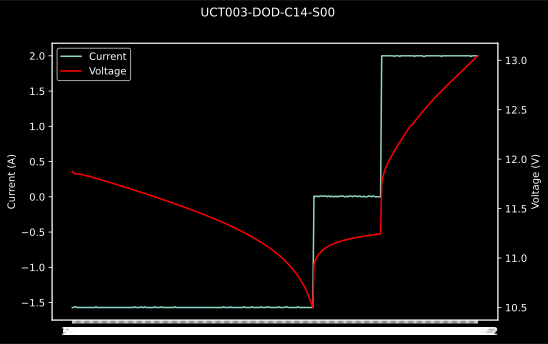

In [20]:
def plot_current_voltage(df: pd.DataFrame) -> plt.Figure:
    fig, ax = plt.subplots()
    ax2 = ax.twinx()

    ax.plot(df["Total Time"], df["Current"], label="Current")
    ax2.plot(df["Total Time"], df["Voltage"], color="r", label="Voltage")

    ax2.set_ylabel("Voltage (V)")
    ax.set_ylabel("Current (A)")

    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines + lines2, labels + labels2)

    return fig


def plot_all_dod_curves(dod_data: dict, save_dir: str | None = None) -> None:
    def plot_save_curve(file, df) -> None:
        fig = plot_current_voltage(df)
        fig.suptitle(file)

        if save_dir:
            fig.savefig(f"{save_dir}/{file}.png")
        return fig

    with futures.ThreadPoolExecutor() as executor:
        executor.map(lambda item: plot_save_curve(*item), dod_data.items())


os.makedirs(PLOTS_DIR, exist_ok=True)
plot_all_dod_curves(dod_data, PLOTS_DIR)

None

## Comparison of Depth of Discharge Curves

IndexError: single positional indexer is out-of-bounds

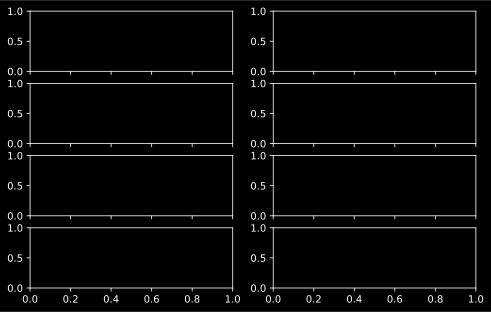

In [ ]:
# def plot_dod_steps(ax: List[plt.Axes], df: pd.DataFrame) -> None:
#     # Split data by Step
#     steps = df["Step"].unique()
#     init_discharge = df[df["Mode"] == "Discharge"].iloc[0]


# fig, ax = plt.subplots(4, 2, sharex=True)

# for file, df in dod_data.items():
#     plot_dod_steps(ax, df)